In [20]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import optax

from temgym_core.constants import energy2wavelength
from temgym_core.components import Lens, Detector
import sympy as sp

# Import the transfer_matrices module
import sys
sys.path.insert(0, '/home/dl277493/Documents/Code/TemGymCore/tests')
from transfer_matrices import full_abcd_2lens, lens_matrix, propagation_matrix, calculate_z1_and_z2_from_M_and_f, imaging_matrix

jax.config.update("jax_enable_x64", True)

%matplotlib widget

In [21]:
# FFT-based Collins propagation with properly decoupled magnification
@jax.jit
def collins_propagate_fft_core(U_in, A, B, wavelength, input_window_width):
    """
    Collins FFT-based propagation using paraxial Fresnel diffraction.

    Key Physics Insight: In imaging systems with ABCD constraints,
    magnification and defocus decouple completely:

    Constraints:
    - A = M_measured (magnification)
    - B = M_measured * z_defocus (defocus constraint)

    Therefore: B/A = z_defocus

    This means the Fresnel kernel depends ONLY on z_defocus, not on M!

    The diffraction is pure free-space Fresnel propagation by z_defocus:
    H(f) = exp(-i*pi*lambda*z_defocus*f^2)

    Magnification M is completely cancelled out. The fringe spacing at the
    detector depends on z_defocus alone, independent of how much the system
    magnifies. (The physical size is scaled by M, but fringe period isn't!)

    Parameters:
    -----------
    U_in : complex array, shape (N, N)
        Input field at the aperture
    A, B : float
        ABCD matrix elements from the optical system
        A: magnification (A = M_measured)
        B: defocus parameter (B = M_measured * z_def)
    wavelength : float
        Wavelength of the wave (meters)
    input_window_width : float
        Physical window size at the input grid (meters)

    Returns:
    --------
    U_out : complex array, shape (N, N)
        Output field at detector plane
        Physical coordinates: [-L/2, L/2] in each dimension

    Notes:
    ------
    The B/A ratio = z_defocus is the effective propagation distance
    governing diffraction. This is:

    1. Numerically stable (no huge A in exponential)
    2. Physically correct (matches imaging behavior)
    3. Clean (just standard Fresnel propagation by z_def)
    4. Elegant (magnification M cancels automatically)
    """
    N = U_in.shape[0]
    dx = input_window_width / N  # Physical pixel size at detector plane

    # Frequency coordinates (cycles per meter)
    f = jnp.fft.fftfreq(N, d=dx)
    fx, fy = jnp.meshgrid(f, f, indexing='ij')
    freq_sq = fx**2 + fy**2

    # Fresnel transfer function with magnification cancellation
    # H(f) = exp(-i*pi*wavelength*(B/A)*f^2)
    # where B/A = z_defocus (from imaging constraints A=M, B=M*z_def)
    z_defocus = B / A  # Simplifies to just the defocus distance
    H = jnp.exp(-1j * jnp.pi * wavelength * z_defocus * freq_sq)

    # FFT-based propagation: apply transfer function in frequency domain
    U_freq = jnp.fft.fft2(U_in, axes=(0, 1))
    U_out_freq = H * U_freq
    U_out = jnp.fft.ifft2(U_out_freq, axes=(0, 1))
    U_out = U_out * 1 / A

    return U_out

def collins_propagate_fft(
    U_in,
    A,
    B,
    wavelength,
    input_window_width,
    output_window_width=None,
    interpolation="linear",
):
    """
    Collins FFT-based propagation with magnification-aware zoom.

    This wrapper returns a normalized intensity image resized to the
    output window width. The zoom factor is based on A and a reference A_ref.
    """
    if output_window_width is None:
        output_window_width = input_window_width

    U_out = collins_propagate_fft_core(
        U_in,
        A=A,
        B=B,
        wavelength=wavelength,
        input_window_width=input_window_width,
    )

    intensity = jnp.abs(U_out)**2
    intensity = intensity / jnp.sum(intensity)

    zoom_factor = float(jnp.abs(A) * (input_window_width / output_window_width))
    N = intensity.shape[0]
    new_size = max(1, int(round(N * zoom_factor)))

    intensity = jax.image.resize(intensity, (new_size, new_size), method=interpolation)

    if new_size < N:
        pad_total = N - new_size
        pad_before = pad_total // 2
        pad_after = pad_total - pad_before
        intensity = jnp.pad(intensity, ((pad_before, pad_after), (pad_before, pad_after)))
    elif new_size > N:
        start = (new_size - N) // 2
        intensity = intensity[start:start + N, start:start + N]

    intensity = intensity / jnp.sum(intensity)

    return intensity

print("FFT-based Collins propagator initialized")
print("✓ B/A = z_defocus (magnification M cancels completely)")
print("✓ Diffraction is pure Fresnel over defocus distance")
print("✓ Fringe spacing independent of magnification M")
print("✓ Zoom handled inside Collins wrapper")

FFT-based Collins propagator initialized
✓ B/A = z_defocus (magnification M cancels completely)
✓ Diffraction is pure Fresnel over defocus distance
✓ Fringe spacing independent of magnification M
✓ Zoom handled inside Collins wrapper


In [28]:

# Geometry and forward model
voltage = 100_000  # V
wavelength = energy2wavelength(voltage)

# Geometry
input_window_width = 10e-3  # 10 mm detector (physical size on detector plane)
aperture_radius = 1e-6      # 1 µm source aperture

# True parameters for synthetic data
# Magnification A ~ 10mm / 1µm = 10,000
# This is a highly magnified imaging setup

f1_true = 2.5e-5
f2_true = 5e-4
M1 = -100
M2 = -20

z1_lens_1, z2_lens_1 = calculate_z1_and_z2_from_M_and_f(M1, f1_true)
z1_lens_2, z2_lens_2 = calculate_z1_and_z2_from_M_and_f(M2, f2_true)

z1_def_val = 1e-2
z1_true = abs(z1_lens_1)
z2_true = abs(z2_lens_1) + abs(z1_lens_2)
z3_true = abs(z2_lens_2)

# Create TemGym component objects for proper physical grid definition
lens1 = Lens(z=z1_true, focal_length=f1_true)
lens2 = Lens(z=z1_true + z2_true, focal_length=f2_true)

print(f"Total distances: z1 = {z1_true:.2e} m, z2 = {z2_true:.2e} m, z3 = {z3_true:.2e} m")
print(f"\nTemGym Components:")
print(f"  Lens 1: z={lens1.z*1e3:.6f} mm, f={lens1.focal_length*1e3:.6f} mm")
print(f"  Lens 2: z={lens2.z*1e3:.6f} mm, f={lens2.focal_length*1e3:.6f} mm")
print(f"\nVery high magnification regime:")
print(f"  Aperture size: {aperture_radius*1e6:.2f} µm")
print(f"  Detector size: {input_window_width*1e3:.2f} mm")
print(f"  Expected A ≈ {input_window_width / aperture_radius:.0f}")
print(f"\n⚠️  WARNING: 256×256 grid cannot fully resolve diffraction at this magnification!")
print(f"    For proper sampling, consider:")
print(f"    - Use higher resolution grid (512×512 or 1024×1024)")
print(f"    - Or reduce detector size / increase aperture size")
print(f"    - Or use only the central region of the magnified image")

z1_def = sp.symbols('z1_def')
# Compute symbolic ABCD matrix with symbolic=True
z1_sym_abcd, z2_sym_abcd, z3_sym_abcd, f1_sym_abcd, f2_sym_abcd = sp.symbols('z1 z2 z3 f1 f2')
M_symbolic = full_abcd_2lens((z1_sym_abcd + z1_def, z2_sym_abcd, z3_sym_abcd), f1_sym_abcd, f2_sym_abcd, symbolic=True)
display(M_symbolic)
M_true = full_abcd_2lens((z1_true + z1_def_val, z2_true, z3_true), f1_true, f2_true, symbolic=False)
print(M_true)

imaging_matrix_1 = imaging_matrix(M1, f1_true) @ propagation_matrix(z1_def_val)
imaging_matrix_2 = imaging_matrix(M2, f2_true)

total = imaging_matrix_2 @ imaging_matrix_1


eq_A = sp.Eq(sp.symbols('A'), M_symbolic[0, 0])

eq_B = sp.Eq(sp.symbols('B'), M_symbolic[0, 1])

display(eq_B)
display(eq_A)

Total distances: z1 = 2.53e-05 m, z2 = 3.05e-03 m, z3 = 1.05e-02 m

TemGym Components:
  Lens 1: z=0.025250 mm, f=0.025000 mm
  Lens 2: z=3.075250 mm, f=0.500000 mm

Very high magnification regime:
  Aperture size: 1.00 µm
  Detector size: 10.00 mm
  Expected A ≈ 10000

⚠️  WARNING: 256×256 grid cannot fully resolve diffraction at this magnification!
    For proper sampling, consider:
    - Use higher resolution grid (512×512 or 1024×1024)
    - Or reduce detector size / increase aperture size
    - Or use only the central region of the magnified image


Matrix([
[1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1, z2*(1 - z3/f2) + z3 + (z1 + z1_def)*(1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1), 0],
[              -1/f2 - (1 - z2/f2)/f1,                         (-1/f2 - (1 - z2/f2)/f1)*(z1 + z1_def) + 1 - z2/f2, 0],
[                                   0,                                                                          0, 1]])

[[2.0000000e+03 2.0000000e+01 0.0000000e+00]
 [2.0200000e+05 2.0200005e+03 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]


Eq(B, z2*(1 - z3/f2) + z3 + (z1 + z1_def)*(1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1))

Eq(A, 1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1)


True parameters:
  f1 = 0.025000 mm
  f2 = 0.500000 mm
  z1 = 0.025250 mm
  z2 = 3.050000 mm
  z3 = 10.500000 mm

Detector configuration (TemGym):
  Position: z = 13.575250 mm
  Pixel size: 19.53 µm x 19.53 µm
  Shape: 512x512 pixels
  Physical size: 10.0 mm x 10.0 mm

Aperture radius: 1.00 µm (8245+0j pixels)


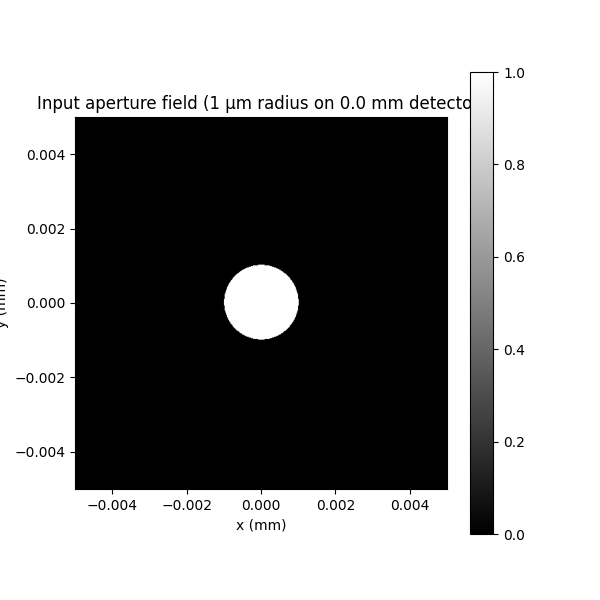

In [29]:
# Grid parameters for Collins FFT propagation using TemGym Detector
# 512×512 resolution ensures proper sampling at ~10,000x magnification
# 1 µm aperture with diffraction rings requires pixel size ~19.5 µm
input_window_width = 10e-6  # 10 µm physical window to focus on central region of magnified image
input_Nx, input_Ny = 512, 512  # Increased to 512 for better sampling at high magnification
input_pixel = input_window_width / input_Nx

output_window_width = 10e-3
output_Nx, output_Ny = 512, 512  # Final image plane grid (can be same as input for simplicity)
output_pixel = output_window_width / output_Nx

input_detector = Detector(
    z=0.0,  # Input plane at z=0
    pixel_size=(input_pixel, input_pixel),
    shape=(input_Ny, input_Nx),
    centre=(0.0, 0.0)
)

# Create TemGym Detector at final image plane for proper grid definition
output_detector = Detector(
    z=z1_true + z2_true + z3_true,  # Final image plane
    pixel_size=(output_pixel, output_pixel),
    shape=(output_Ny, output_Nx),
    centre=(0.0, 0.0)
)

# Use detector coordinates for grid
input_x, input_y = input_detector.coords_1d
xx, yy = jnp.meshgrid(input_x, input_y, indexing='ij')

# Circular aperture: 1 inside aperture radius, 0 outside
radial_dist = jnp.sqrt(xx**2 + yy**2)
U_aperture = (radial_dist <= aperture_radius).astype(jnp.complex64)

print(f'\nTrue parameters:')
print(f'  f1 = {f1_true*1e3:.6f} mm')
print(f'  f2 = {f2_true*1e3:.6f} mm')
print(f'  z1 = {z1_true*1e3:.6f} mm')
print(f'  z2 = {z2_true*1e3:.6f} mm')
print(f'  z3 = {z3_true*1e3:.6f} mm')
print(f'\nDetector configuration (TemGym):')
print(f'  Position: z = {output_detector.z*1e3:.6f} mm')
print(f'  Pixel size: {output_detector.pixel_size[0]*1e6:.2f} µm x {output_detector.pixel_size[1]*1e6:.2f} µm')
print(f'  Shape: {output_detector.shape[0]}x{output_detector.shape[1]} pixels')
print(f'  Physical size: {output_window_width*1e3:.1f} mm x {output_window_width*1e3:.1f} mm')
print(f'\nAperture radius: {aperture_radius*1e6:.2f} µm ({jnp.sum(U_aperture).item():.0f} pixels)')

# Visualize input aperture
plt.figure(figsize=(6, 6))
plt.imshow(np.abs(U_aperture)**2, extent=[-input_window_width/2*1e3, input_window_width/2*1e3, 
                                            -input_window_width/2*1e3, input_window_width/2*1e3], 
           origin='lower', cmap='gray')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title(f'Input aperture field (1 µm radius on {input_window_width*1e3:.1f} mm detector)')
plt.colorbar()
plt.show()

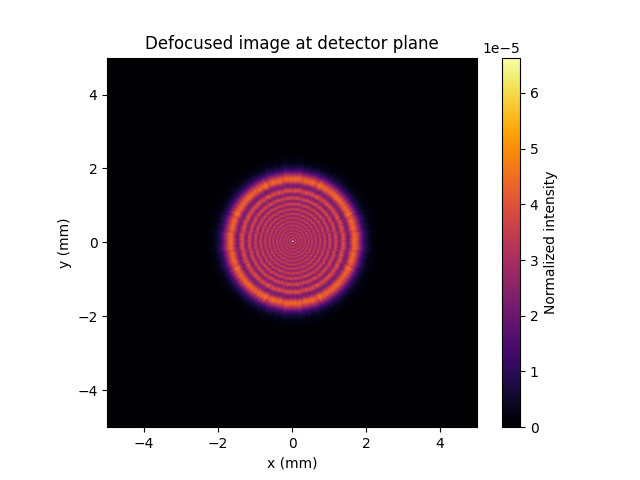

In [35]:
10e-6 * 50000

defocused_image = collins_propagate_fft(
    U_in=U_aperture,
    A=M_true[0, 0],
    B=M_true[0, 1],
    wavelength=wavelength,
    input_window_width=input_window_width,
    output_window_width=output_window_width,
    interpolation='cubic'
)

plt.figure()
plt.imshow(defocused_image, extent=[-output_window_width/2*1e3, output_window_width/2*1e3, 
                                     -output_window_width/2*1e3, output_window_width/2*1e3], 
           origin='lower', cmap='inferno')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Defocused image at detector plane')
plt.colorbar(label='Normalized intensity')
plt.show()